In [1]:
import pickle
import pandas as pd
import numpy as np
import xgboost as xgboost
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [81]:
df = pd.read_csv('Insurance Premium Prediction Dataset.csv/insurance_claim_prediction.csv')
df.head()

,policy_id,policy_state,policy_deductable,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,total_claim_amount
0,1000000,OH,2000,1529.859860,52.0,FEMALE,High School,Craft-repair,Biking,Parked Car,Front Collision,Trivial Damage,Fire,3,3,1,2.0,NO,9458.62
1,1000001,IL,500,947.425112,69.0,FEMALE,Associate,Armed-forces,Cross-fit,Parked Car,Front Collision,Total Loss,Fire,13,2,2,4.0,YES,79619.62
2,1000002,FL,1000,1171.505698,55.0,MALE,PhD,Craft-repair,Chess,Parked Car,Rear Collision,NaN,Ambulance,9,4,2,4.0,YES,68920.70
3,1000003,OH,2000,976.162998,26.0,FEMALE,High School,Craft-repair,Cross-fit,Single Vehicle Collision,Side Collision,Major Damage,Ambulance,19,4,2,0.0,NO,46109.01
4,1000004,TX,2000,1302.617099,19.0,FEMALE,Associate,Armed-forces,Exercise,Single Vehicle Collision,Side Collision,Total Loss,Ambulance,14,2,0,0.0,YES,66060.15


In [82]:
df.drop('policy_id', inplace=True, axis=1)

In [83]:
df.columns

Index(['policy_state', 'policy_deductable', 'policy_annual_premium',
       'insured_age', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'police_report_available',
       'total_claim_amount'],
      dtype='object')

In [84]:
df.shape

(200000, 18)

In [85]:
df.isnull().sum()

policy_state                       0
policy_deductable                  0
policy_annual_premium           3000
insured_age                     3000
insured_sex                        0
insured_education_level         3000
insured_occupation                 0
insured_hobbies                    0
incident_type                      0
collision_type                     0
incident_severity               3000
authorities_contacted          52085
incident_hour_of_the_day           0
number_of_vehicles_involved        0
bodily_injuries                    0
witnesses                       3000
police_report_available            0
total_claim_amount                 0
dtype: int64

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   policy_state                 200000 non-null  object 
 1   policy_deductable            200000 non-null  int64  
 2   policy_annual_premium        197000 non-null  float64
 3   insured_age                  197000 non-null  float64
 4   insured_sex                  200000 non-null  object 
 5   insured_education_level      197000 non-null  object 
 6   insured_occupation           200000 non-null  object 
 7   insured_hobbies              200000 non-null  object 
 8   incident_type                200000 non-null  object 
 9   collision_type               200000 non-null  object 
 10  incident_severity            197000 non-null  object 
 11  authorities_contacted        147915 non-null  object 
 12  incident_hour_of_the_day     200000 non-null  int64  
 13 

## Handling Missing Values

<Axes: xlabel='policy_annual_premium', ylabel='Count'>

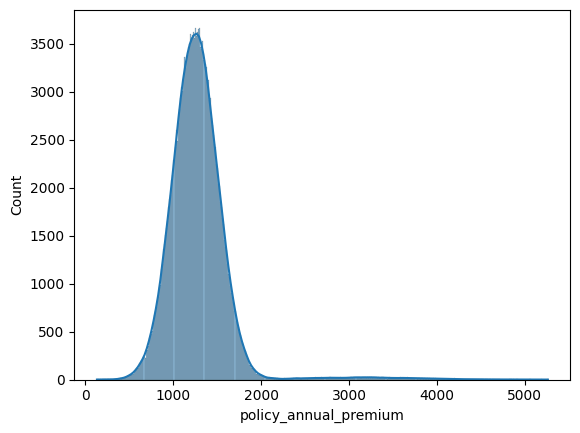

In [87]:
import seaborn as sns

sns.histplot(df['policy_annual_premium'], kde=True)

In [88]:
df['policy_annual_premium'].mean()

np.float64(1277.960731987874)

In [89]:
df['policy_annual_premium']=df['policy_annual_premium'].fillna(df['policy_annual_premium'].mean())

In [90]:
df['policy_annual_premium'].isnull().sum()

np.int64(0)

<Axes: xlabel='insured_age', ylabel='Count'>

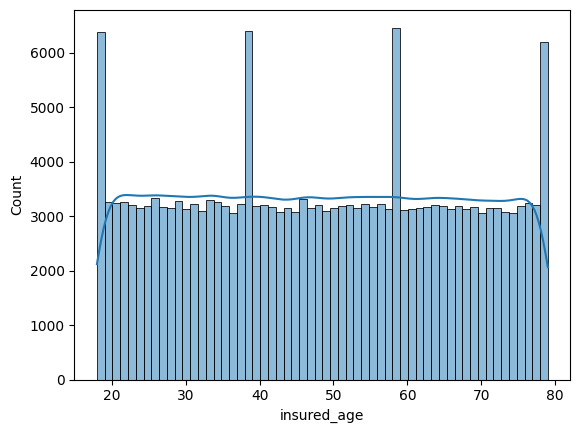

In [91]:
sns.histplot(df['insured_age'], kde=True)

In [92]:
df['insured_age']=df['insured_age'].fillna(df['insured_age'].mean())

In [93]:
df['insured_age'].isnull().sum()

np.int64(0)

<Axes: xlabel='insured_education_level', ylabel='Count'>

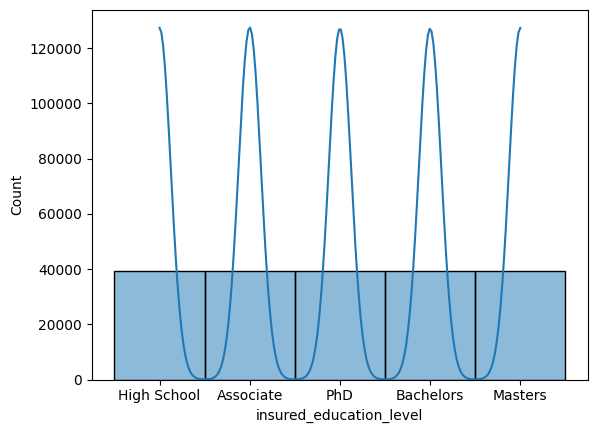

In [94]:
# insured_education_level
sns.histplot(df['insured_education_level'], kde=True)

In [95]:
df['insured_education_level']=df['insured_education_level'].fillna(df['insured_education_level'].mode()[0])

In [96]:
df['insured_education_level'].isnull().sum()

np.int64(0)

In [97]:
df['incident_severity']=df['incident_severity'].fillna(df['incident_severity'].mode()[0])
df['witnesses']=df['witnesses'].fillna(df['witnesses'].mode()[0])
df['authorities_contacted']=df['authorities_contacted'].fillna(df['authorities_contacted'].mode()[0])

In [98]:
df.isnull().sum()

policy_state                   0
policy_deductable              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
total_claim_amount             0
dtype: int64

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   policy_state                 200000 non-null  object 
 1   policy_deductable            200000 non-null  int64  
 2   policy_annual_premium        200000 non-null  float64
 3   insured_age                  200000 non-null  float64
 4   insured_sex                  200000 non-null  object 
 5   insured_education_level      200000 non-null  object 
 6   insured_occupation           200000 non-null  object 
 7   insured_hobbies              200000 non-null  object 
 8   incident_type                200000 non-null  object 
 9   collision_type               200000 non-null  object 
 10  incident_severity            200000 non-null  object 
 11  authorities_contacted        200000 non-null  object 
 12  incident_hour_of_the_day     200000 non-null  int64  
 13 

## Outlier Treatement using IQR

In [100]:
numerical_col = df.select_dtypes(['int64', 'float64']).columns
categorical_col = df.select_dtypes(['object']).columns
print(numerical_col)
print(categorical_col)

Index(['policy_deductable', 'policy_annual_premium', 'insured_age',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'total_claim_amount'],
      dtype='object')
Index(['policy_state', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'police_report_available'],
      dtype='object')


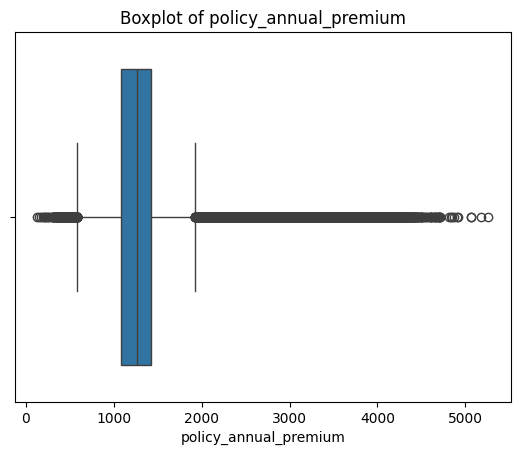

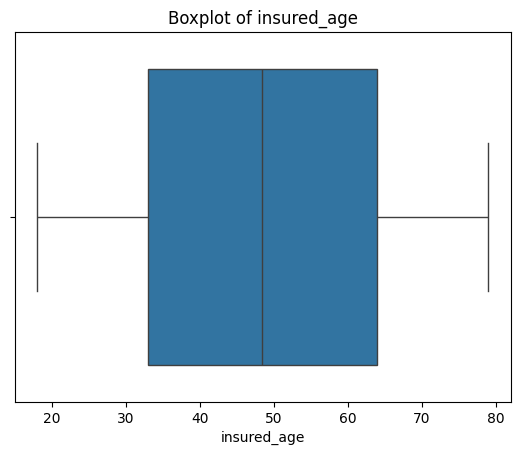

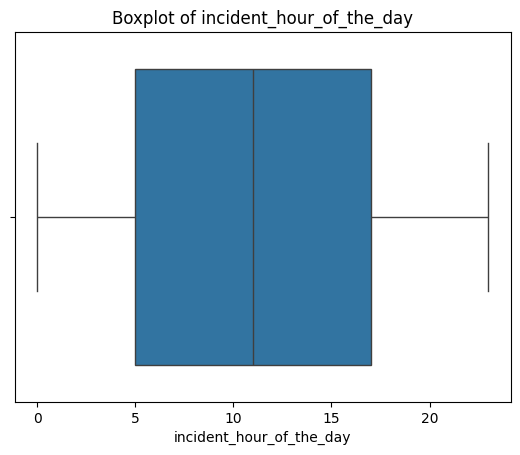

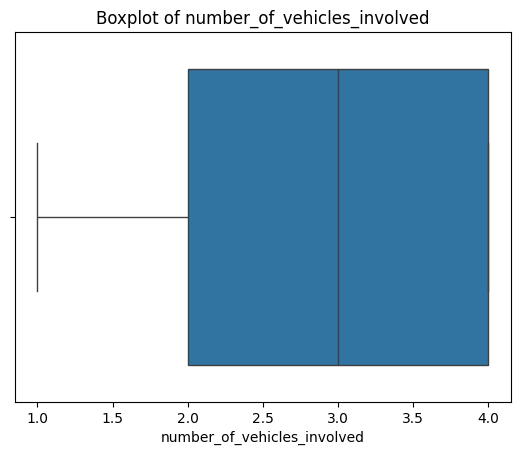

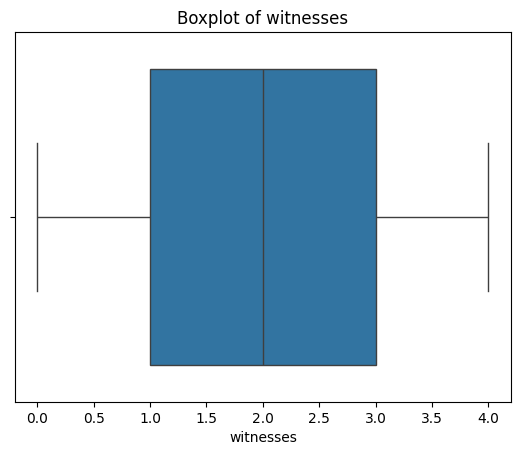

In [101]:
from matplotlib import pyplot as plt

for col in numerical_col.drop(['policy_deductable', 'bodily_injuries', 'total_claim_amount']):
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [102]:
def outlier_tretement_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1-1.5*iqr
    upper_limit = q3+1.5*iqr
    return lower_limit, upper_limit

In [103]:
df_without_oulier_iqr = df.copy()
for col in numerical_col:
    low, high = outlier_tretement_iqr(df, col)
    df_without_oulier_iqr[col] = df[col].clip(lower=low, upper=high)

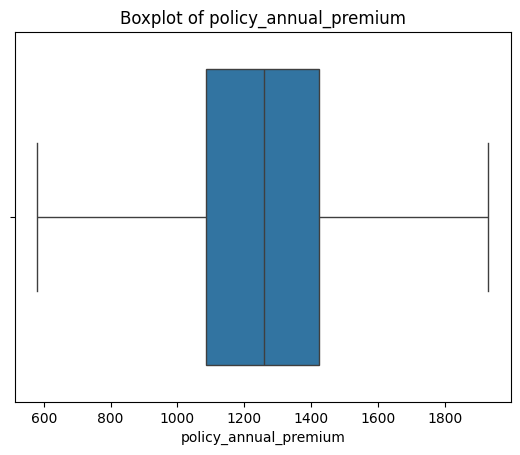

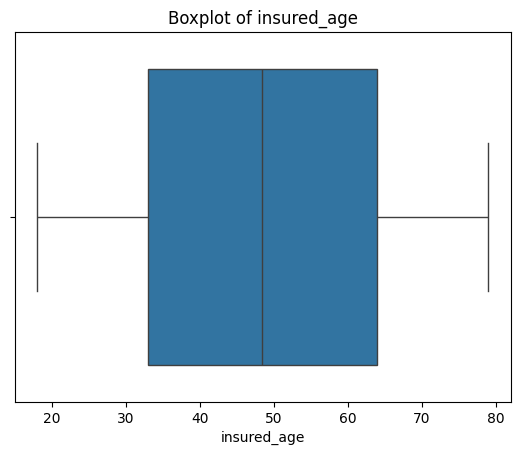

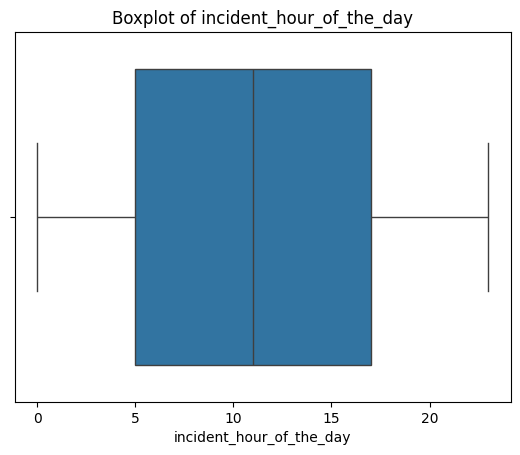

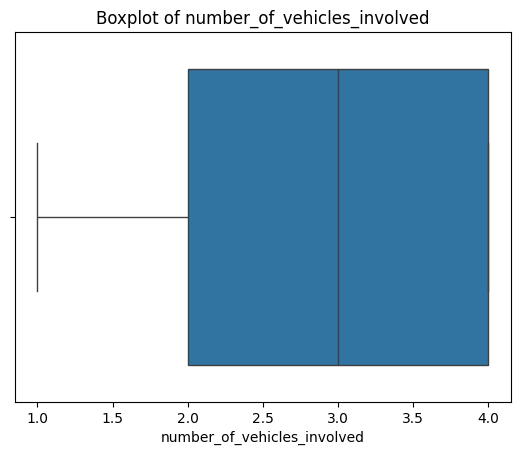

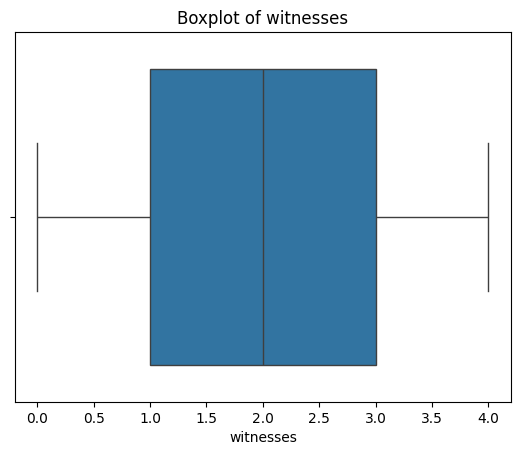

In [104]:
for col in numerical_col.drop(['policy_deductable', 'bodily_injuries', 'total_claim_amount']):
    sns.boxplot(data=df_without_oulier_iqr, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [105]:
print(f"Original Max: {df['price'].max()}")
print(f"Cleaned Max:  {df_without_oulier_iqr['price'].max()}")

KeyError: 'price'